In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
disease_data= pd.read_csv('C:\Study content\ML\DATASETS\Heart_Disease.csv')

disease_data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
disease_data.drop(columns=['education'], inplace = True)
disease_data.rename(columns ={'male':'Sex_male'}, inplace = True)
disease_data.head()

,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [9]:
X = disease_data[['Sex_male','age','cigsPerDay','totChol','sysBP','glucose']]
Y = disease_data['TenYearCHD']
X = X.fillna(X.mean())
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size = 0.3, random_state = 4)

scaler = StandardScaler()
X = scaler.fit_transform(X)
print(f"Train Set: {X_train.shape}, {y_train.shape}")
print(f"Test Set: {X_test.shape}, {y_test.shape}")

Train Set: (2968, 6), (2968,)
Test Set: (1272, 6), (1272,)


C:\Users\Acer\AppData\Local\Temp\ipykernel_15840\565543027.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD', data=disease_data, palette= 'BuGn_r')


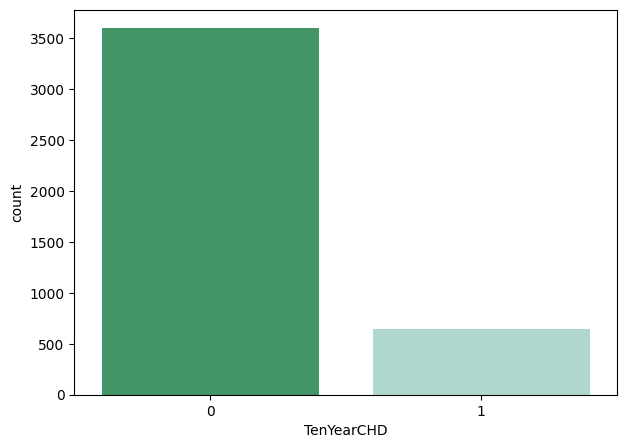

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='TenYearCHD', data=disease_data, palette= 'BuGn_r')
plt.show()

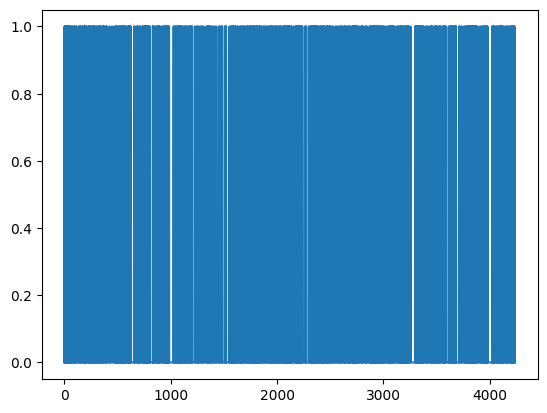

In [ ]:
laste = disease_data['TenYearCHD'].plot()
plt.show()

In [11]:
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
print(f"Predicted values:{logmodel.predict(X_test)}")
print(f"Classification Report:\n{classification_report(y_test, logmodel.predict(X_test))}")
print(f"Accuracy score: {accuracy_score(y_test, logmodel.predict(X_test))}")


Predicted values:[0 0 0 ... 0 0 0]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      1084
           1       0.69      0.06      0.11       188

    accuracy                           0.86      1272
   macro avg       0.77      0.53      0.52      1272
weighted avg       0.83      0.86      0.80      1272

Accuracy score: 0.8569182389937107


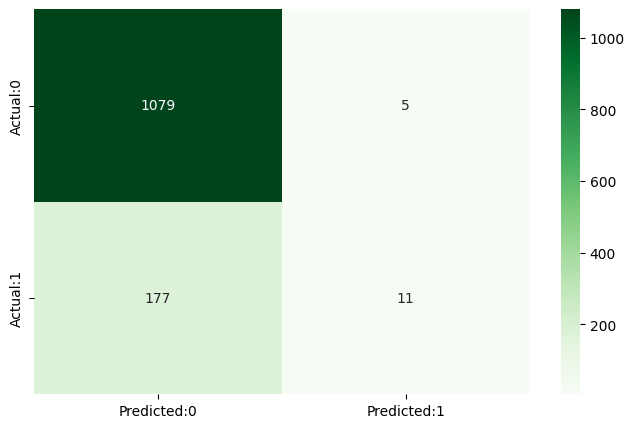

In [13]:
Y_pred = logmodel.predict(X_test)
cm = confusion_matrix(y_test, Y_pred)
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")

plt.show()